Lokman GAOUA 12210750

Partie 1.1: Modélisation de la croissance bactérienne

In [5]:
import numpy as np

In [6]:
import matplotlib.pyplot as plt

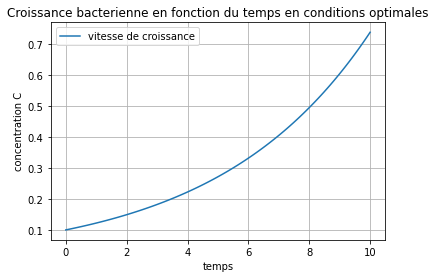

In [18]:
rmax = 0.2 
C0 = 0.1 
T = 10 
dt=0.1
time = np.linspace(0, T, N_steps)
C = C0 * np.exp(rmax * time)

N_steps = int(T / dt)
plt.title('Croissance bacterienne en fonction du temps en conditions optimales') 
plt.plot(time, C, label='vitesse de croissance') 
# Nom de la courbe
plt.xlabel('temps') # Axe des X
plt.ylabel('concentration C') # Axe des Y
plt.grid(True)
plt.legend()
plt.show()

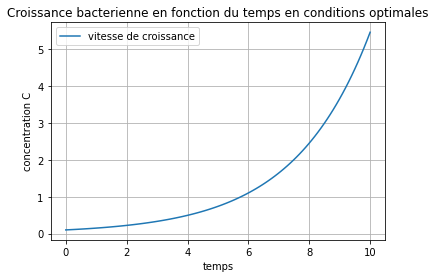

In [20]:
rmax = 0.4
C0 = 0.1 
T = 10 
dt=0.1
time = np.linspace(0, T, N_steps)
C = C0 * np.exp(rmax * time)

N_steps = int(T / dt)
plt.title('Croissance bacterienne en fonction du temps en conditions optimales') 
plt.plot(time, C, label='vitesse de croissance') 
# Nom de la courbe
plt.xlabel('temps') # Axe des X
plt.ylabel('concentration C') # Axe des Y
plt.grid(True)
plt.legend()
plt.show()

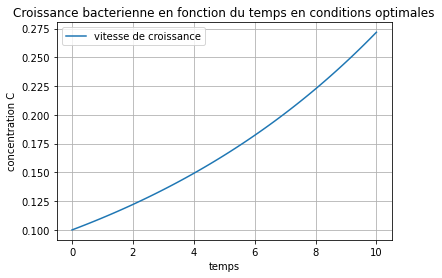

In [21]:
rmax = 0.1
C0 = 0.1 
T = 10 
dt=0.1
time = np.linspace(0, T, N_steps)
C = C0 * np.exp(rmax * time)

N_steps = int(T / dt)
plt.title('Croissance bacterienne en fonction du temps en conditions optimales') 
plt.plot(time, C, label='vitesse de croissance') 
# Nom de la courbe
plt.xlabel('temps') # Axe des X
plt.ylabel('concentration C') # Axe des Y
plt.grid(True)
plt.legend()
plt.show()

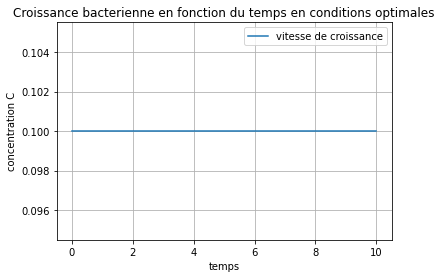

In [22]:
rmax = 0
C0 = 0.1 
T = 10 
dt=0.1
time = np.linspace(0, T, N_steps)
C = C0 * np.exp(rmax * time)

N_steps = int(T / dt)
plt.title('Croissance bacterienne en fonction du temps en conditions optimales') 
plt.plot(time, C, label='vitesse de croissance') 
# Nom de la courbe
plt.xlabel('temps') # Axe des X
plt.ylabel('concentration C') # Axe des Y
plt.grid(True)
plt.legend()
plt.show()

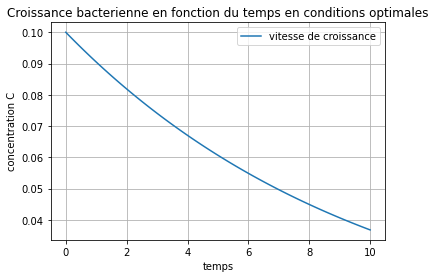

In [23]:
rmax = -0.1 
C0 = 0.1 
T = 10 
dt=0.1
time = np.linspace(0, T, N_steps)
C = C0 * np.exp(rmax * time)

N_steps = int(T / dt)
plt.title('Croissance bacterienne en fonction du temps en conditions optimales') 
plt.plot(time, C, label='vitesse de croissance') 
# Nom de la courbe
plt.xlabel('temps') # Axe des X
plt.ylabel('concentration C') # Axe des Y
plt.grid(True)
plt.legend()
plt.show()

1.Ce type de courbe s'appelle une courbe croissante

2.La population a doublée en environ 3h30

3. Lorsque r est nul, la concentration n'évolue pas, elle reste constante. POur r négatif, la concentration devient décroissante.

4.Ce modèle a pour limite d'étre pris dans des conditions idéales, ce qui dans des conditions experimentales est très rare. Il faudrait pouvoir moduler les ressources pour la simulation


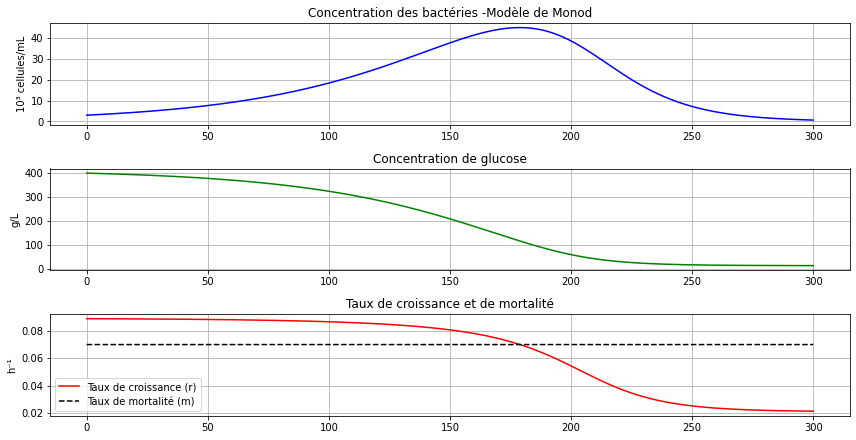

In [46]:
# ======================# PARAMÈTRES DE LA SIMULATION# ======================
T = 300 # Durée totale (heures)
dt = 0.1 # Pas de temps (heures)
N_steps = int(T / dt) # Nombre de pas de temps
# ======================# PARAMÈTRES DE LA SOUCHE# ======================
rmax = 0.10 # Taux de croissance maximal (h⁻¹)
K = 50 # Affinité pour le substrat (g/L)
m0 = 0.07 # Taux de mortalité minimal (h⁻¹)
C0 = 3 # Concentration initiale de bactéries (10³ cellules/mL)
# ======================# PARAMÈTRES DU SUBSTRAT (GLUCOSE)#======================
initial_glucose = 400 # Concentration initiale de glucose (g/L)
glucose_inflow = 0 # Flux entrant de glucose (g/L/h)
# ======================# INITIALISATION DES TABLEAUX# ======================
C = np.zeros(N_steps) # Concentration bactérienne
glucose_level = np.zeros(N_steps)
growth_rate = np.zeros(N_steps)
mortality_rate = np.zeros(N_steps)
# ======================# CONDITIONS INITIALES# ======================
C[0] = C0
glucose_level[0] = initial_glucose
growth_rate[0] = rmax * glucose_level[0] / (K + glucose_level[0])
mortality_rate[0] = m0
# ======================# SIMULATION# ======================
for i in range(1, N_steps):
    # Calcul des taux 
    r = rmax * glucose_level[i-1] / (K + glucose_level[i-1])
    # Mise à jour de la population bactérienne
    C[i] = C[i-1] + dt * (r -m0) * C[i-1]
    # Mise à jour du glucose (consommation + flux entrant)
    glucose_level[i] = glucose_level[i-1] -dt * r * C[i-1] + glucose_inflow * dt
    # Stockage des taux
    growth_rate[i] = r
    mortality_rate[i] = m0
# ======================# AXE DES X EN HEURES# ======================
time = np.linspace(0, T, N_steps)
# ======================# TRACÉ DES COURBES# ======================
plt.figure(figsize=(12, 8))
# 1. Concentration bactérienne
plt.subplot(4, 1, 1)
plt.plot(time, C, label='Nombre de bactéries', color='blue')
plt.title('Concentration des bactéries -Modèle de Monod')
plt.ylabel('10³ cellules/mL')
plt.grid(True)
# 2. Concentration de glucose
plt.subplot(4, 1, 2)
plt.plot(time, glucose_level, label='Concentration de glucose', color='green')
plt.title('Concentration de glucose')
plt.ylabel('g/L')
plt.grid(True)
# 3. Taux de croissance ET mortalité (sur le même graphique)
plt.subplot(4, 1, 3)
plt.plot(time, growth_rate, label='Taux de croissance (r)', color='red')
plt.plot(time, mortality_rate, label='Taux de mortalité (m)', color='black', linestyle='--') # Ligne noire en pointillé
plt.title('Taux de croissance et de mortalité')
plt.ylabel('h⁻¹')
plt.legend() # Affiche la légende pour les deux courbes
plt.grid(True)
plt.tight_layout()
plt.show()

1.La courbe de la concentration en glucose est décroissante, avec un plateau à partir de C=50 g/L environ.
A ce moment, la courbe représentant le nombre de bactérie qui etait croissante jusqu'alors, atteint son pic et devient décroissante. Le taux de croissance semble lié à la concentration de glucose, car les 2 courbes ont une allure similaire, et le taux de mortalité est invariable, à 0.07. 
On comprend que la concentration en bactérie devient décroissante quand r devient inférieur à m (on a plus de bactérie qui meurent que de divisions) 

2.Ce modèle est plus précis que le précédent, mais il ne prends en compte qu'une souche bactierienne isolée des autres, ce qui n'est en général pas le cas en milieu sauvage.

3.La population décroit pour r < m 

4.Pour que cette population se maintienne dans le temps, il faudrait  une concentration en glucose toujours au dessus du seuil à partir duquel le taux de croissance passe en deça du taux de mortalité.

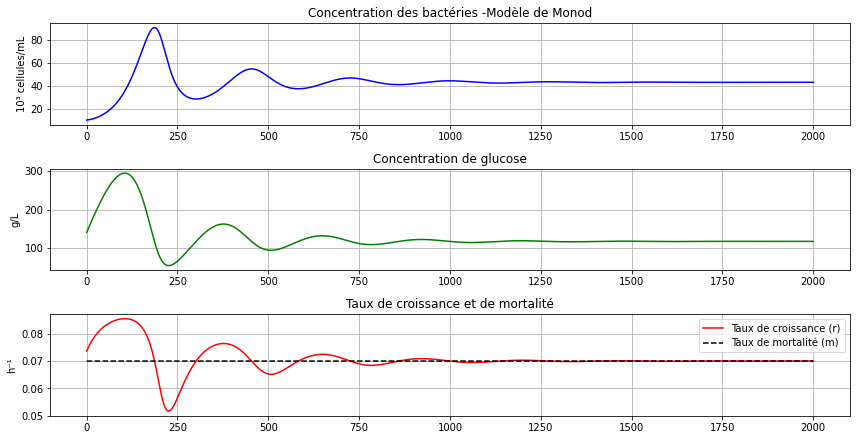

In [47]:
# ======================# PARAMÈTRES DE LA SIMULATION# ======================
T = 2000 # Durée totale (heures)
dt = 0.1 # Pas de temps (heures)
N_steps = int(T / dt) # Nombre de pas de temps
# ======================# PARAMÈTRES DE LA SOUCHE# ======================
rmax = 0.10 # Taux de croissance maximal (h⁻¹)
K = 50 # Affinité pour le substrat (g/L)
m0 = 0.07 # Taux de mortalité minimal (h⁻¹)
C0 = 10 # Concentration initiale de bactéries (10³ cellules/mL)
# ======================# PARAMÈTRES DU SUBSTRAT (GLUCOSE)#======================
initial_glucose = 140 # Concentration initiale de glucose (g/L)
glucose_inflow = 3 # Flux entrant de glucose (g/L/h)
# ======================# INITIALISATION DES TABLEAUX# ======================
C = np.zeros(N_steps) # Concentration bactérienne
glucose_level = np.zeros(N_steps)
growth_rate = np.zeros(N_steps)
mortality_rate = np.zeros(N_steps)
# ======================# CONDITIONS INITIALES# ======================
C[0] = C0
glucose_level[0] = initial_glucose
growth_rate[0] = rmax * glucose_level[0] / (K + glucose_level[0])
mortality_rate[0] = m0
# ======================# SIMULATION# ======================
for i in range(1, N_steps):
    # Calcul des taux 
    r = rmax * glucose_level[i-1] / (K + glucose_level[i-1])
    # Mise à jour de la population bactérienne
    C[i] = C[i-1] + dt * (r -m0) * C[i-1]
    # Mise à jour du glucose (consommation + flux entrant)
    glucose_level[i] = glucose_level[i-1] -dt * r * C[i-1] + glucose_inflow * dt
    # Stockage des taux
    growth_rate[i] = r
    mortality_rate[i] = m0
# ======================# AXE DES X EN HEURES# ======================
time = np.linspace(0, T, N_steps)
# ======================# TRACÉ DES COURBES# ======================
plt.figure(figsize=(12, 8))
# 1. Concentration bactérienne
plt.subplot(4, 1, 1)
plt.plot(time, C, label='Nombre de bactéries', color='blue')
plt.title('Concentration des bactéries -Modèle de Monod')
plt.ylabel('10³ cellules/mL')
plt.grid(True)
# 2. Concentration de glucose
plt.subplot(4, 1, 2)
plt.plot(time, glucose_level, label='Concentration de glucose', color='green')
plt.title('Concentration de glucose')
plt.ylabel('g/L')
plt.grid(True)
# 3. Taux de croissance ET mortalité (sur le même graphique)
plt.subplot(4, 1, 3)
plt.plot(time, growth_rate, label='Taux de croissance (r)', color='red')
plt.plot(time, mortality_rate, label='Taux de mortalité (m)', color='black', linestyle='--') # Ligne noire en pointillé
plt.title('Taux de croissance et de mortalité')
plt.ylabel('h⁻¹')
plt.legend() # Affiche la légende pour les deux courbes
plt.grid(True)
plt.tight_layout()
plt.show()

1.Les 3 courbes présentent le même chemin suivi, des variations de plus en plus petites, puis une stabilisation à une certaine valeur 

2.La population bacterienne subit des fluctuation avant de se stabiliser car la courbe du glucose suit ce même tracé, influencant le taux de croissance, qui va fluctuer en dessous et au dessus du taux de mortalité, avant de se stabiliser au même niveau (r=m), stabilisant ainsi la population (autant de mort que de division)

PARTIE 1.2 : Modélisation de la séléction naturelle

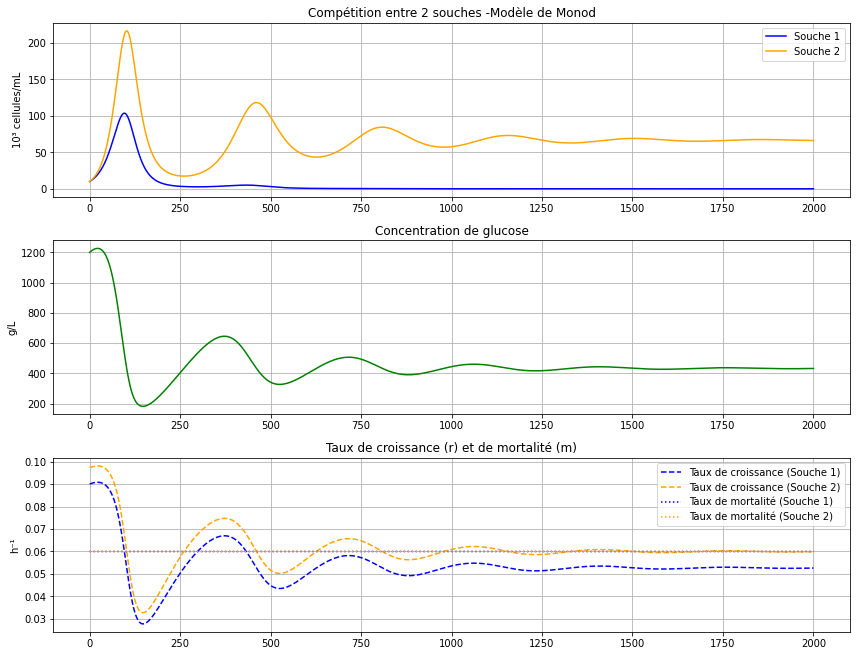

In [60]:
import numpy as np
import matplotlib.pyplot as plt
# =============================================# Paramètres pour la souche 1# =============================================
rmax_1 = 0.15 # Taux de croissance maximal (souche 1)
m0_1 = 0.06 # Taux de mortalité de base(souche 1)
K_1 = 800 # Constante de demi-saturation (souche 1)
# =============================================# Paramètres pour la souche 2# =============================================
rmax_2 = 0.15 # Taux de croissance maximal (souche 2)
m0_2 = 0.06 # Taux de mortalité de base (souche 2)
K_2 = 650 # Constante de demi-saturation (souche 2) -affinité plus élevée pour le glucose
# =============================================# Paramètres du glucose# =============================================
initial_glucose = 1200 # Quantité initiale de glucose
glucose_inflow = 4 # Flux entrant de glucose (0 = système fermé)
# =============================================# Conditions initiales# =============================================
C0_1 = 10 # Concentration initiale de la souche 1
C0_2 = 10 # Concentration initiale de la souche 2
# =============================================# Paramètres de la simulation# =============================================
dt = 0.1 # Pas de temps
T = 2000 # Durée totale de la simulation
N_steps = int(T / dt)# Nombre de pas de temps
# =============================================# Initialisation des tableaux# =============================================
C1 = np.zeros(N_steps)
C2 = np.zeros(N_steps)
glucose_level = np.zeros(N_steps)
growth_rate_1 = np.zeros(N_steps)
growth_rate_2 = np.zeros(N_steps)
mortality_rate_1 = np.zeros(N_steps)
mortality_rate_2 = np.zeros(N_steps)
# Conditions initiales
C1[0] = C0_1
C2[0] = C0_2
glucose_level[0] = initial_glucose
growth_rate_1[0] = rmax_1 * glucose_level[0] / (K_1 + glucose_level[0])
growth_rate_2[0] = rmax_2 * glucose_level[0] / (K_2 + glucose_level[0])
mortality_rate_1[0] = m0_1
mortality_rate_2[0] = m0_2
# =============================================# Simulation# =============================================
for i in range(1, N_steps):
    # Calcul des taux de croissance pour chaque souche (modèle de Monod)
    r_1 = rmax_1 *glucose_level[i-1] / (K_1 + glucose_level[i-1])
    r_2 = rmax_2 * glucose_level[i-1] / (K_2 + glucose_level[i-1])
    # Mortalité variable (augmente si le glucose est faible)
    #m_1 = m0_1 + 0.01 * (1 -glucose_level[i-1] / initial_glucose)
    #m_2 =m0_2 + 0.01 * (1 -glucose_level[i-1] / initial_glucose)
    # Mortalité constante
    m_1 = m0_1 
    m_2 = m0_2
    # Mise à jour des populations bactériennes
    C1[i] = C1[i-1] + dt * (r_1 -m_1) * C1[i-1]
    C2[i] = C2[i-1] + dt * (r_2 -m_2) * C2[i-1]
    # Consommation totale de glucose (somme des consommations des deux souches)
    glucose_consumption = (r_1 * C1[i-1] + r_2 * C2[i-1])
    glucose_level[i] = glucose_level[i-1] -dt * glucose_consumption+ glucose_inflow * dt
    # Stockage des taux
    growth_rate_1[i] = r_1
    growth_rate_2[i] = r_2
    mortality_rate_1[i] = m_1
    mortality_rate_2[i] = m_2
# =============================================
# Temps pour l'axe des abscisses# =============================================
time = np.linspace(0, T, N_steps)# =============================================
# Tracé des courbes# =============================================
plt.figure(figsize=(12, 12))# Population des bactéries
plt.subplot(4, 1, 1)
plt.plot(time, C1, label='Souche 1', color='blue')
plt.plot(time, C2, label='Souche 2', color='orange')
plt.title('Compétition entre 2 souches -Modèle de Monod')
plt.ylabel('10³ cellules/mL')
plt.legend()
plt.grid(True)
# Niveau de glucose
plt.subplot(4, 1, 2)
plt.plot(time, glucose_level, label='Glucose', color='green')
plt.title('Concentration de glucose')
plt.ylabel('g/L')
plt.grid(True)
# Taux de croissance et mortalité
plt.subplot(4, 1, 3)
plt.plot(time, growth_rate_1, label='Taux de croissance (Souche 1)', color='blue', linestyle='--')
plt.plot(time, growth_rate_2, label='Taux de croissance (Souche 2)', color='orange', linestyle='--')
plt.plot(time, mortality_rate_1, label='Taux de mortalité (Souche 1)', color='blue', linestyle=':')
plt.plot(time, mortality_rate_2, label='Taux de mortalité (Souche 2)', color='orange', linestyle=':')
plt.title('Taux de croissance (r) et de mortalité (m)')
plt.ylabel('h⁻¹')
plt.legend()
plt.grid(True)
# Taux de mortalité#
#plt.subplot(4, 1, 4)
#plt.plot(time, mortality_rate_1, label='Taux de mortalité (Souche 1)', color='blue', linestyle=':')
#plt.plot(time, mortality_rate_2, label='Taux de mortalité (Souche 2)', color='orange', linestyle=':')
#plt.title('Taux de mortalité (m) au fil du temps')
#plt.xlabel('Temps')
#plt.ylabel('Taux de mortalité (m)')
#plt.legend()
#plt.grid(True)
plt.tight_layout()
plt.show()

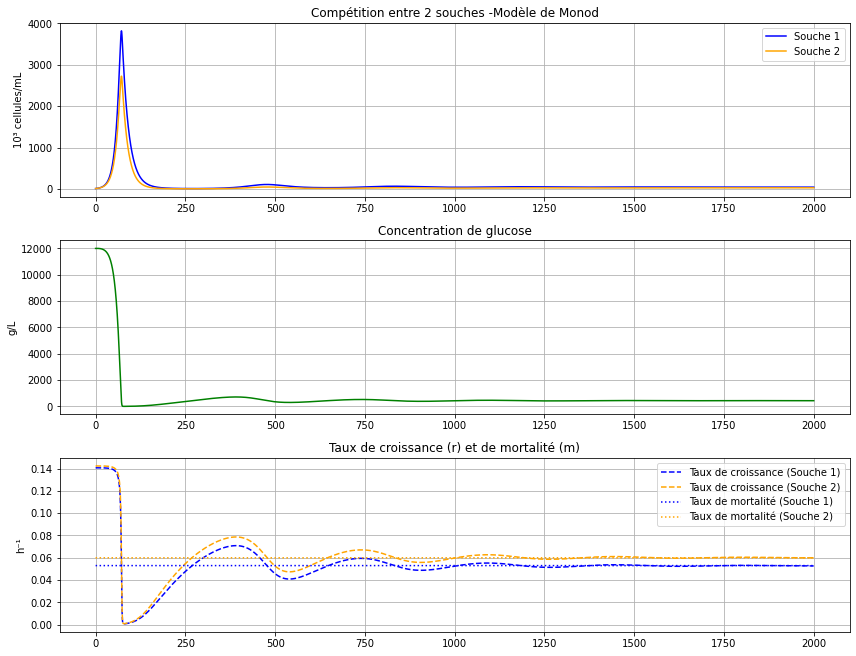

In [63]:
import numpy as np
import matplotlib.pyplot as plt
# =============================================# Paramètres pour la souche 1# =============================================
rmax_1 = 0.15 # Taux de croissance maximal (souche 1)
m0_1 = 0.053 # Taux de mortalité de base(souche 1)
K_1 = 800 # Constante de demi-saturation (souche 1)
# =============================================# Paramètres pour la souche 2# =============================================
rmax_2 = 0.15 # Taux de croissance maximal (souche 2)
m0_2 = 0.06 # Taux de mortalité de base (souche 2)
K_2 = 650 # Constante de demi-saturation (souche 2) -affinité plus élevée pour le glucose
# =============================================# Paramètres du glucose# =============================================
initial_glucose = 12000 # Quantité initiale de glucose
glucose_inflow = 4 # Flux entrant de glucose (0 = système fermé)
# =============================================# Conditions initiales# =============================================
C0_1 = 10 # Concentration initiale de la souche 1
C0_2 = 10 # Concentration initiale de la souche 2
# =============================================# Paramètres de la simulation# =============================================
dt = 0.1 # Pas de temps
T = 2000 # Durée totale de la simulation
N_steps = int(T / dt)# Nombre de pas de temps
# =============================================# Initialisation des tableaux# =============================================
C1 = np.zeros(N_steps)
C2 = np.zeros(N_steps)
glucose_level = np.zeros(N_steps)
growth_rate_1 = np.zeros(N_steps)
growth_rate_2 = np.zeros(N_steps)
mortality_rate_1 = np.zeros(N_steps)
mortality_rate_2 = np.zeros(N_steps)
# Conditions initiales
C1[0] = C0_1
C2[0] = C0_2
glucose_level[0] = initial_glucose
growth_rate_1[0] = rmax_1 * glucose_level[0] / (K_1 + glucose_level[0])
growth_rate_2[0] = rmax_2 * glucose_level[0] / (K_2 + glucose_level[0])
mortality_rate_1[0] = m0_1
mortality_rate_2[0] = m0_2
# =============================================# Simulation# =============================================
for i in range(1, N_steps):
    # Calcul des taux de croissance pour chaque souche (modèle de Monod)
    r_1 = rmax_1 *glucose_level[i-1] / (K_1 + glucose_level[i-1])
    r_2 = rmax_2 * glucose_level[i-1] / (K_2 + glucose_level[i-1])
    # Mortalité variable (augmente si le glucose est faible)
    #m_1 = m0_1 + 0.01 * (1 -glucose_level[i-1] / initial_glucose)
    #m_2 =m0_2 + 0.01 * (1 -glucose_level[i-1] / initial_glucose)
    # Mortalité constante
    m_1 = m0_1 
    m_2 = m0_2
    # Mise à jour des populations bactériennes
    C1[i] = C1[i-1] + dt * (r_1 -m_1) * C1[i-1]
    C2[i] = C2[i-1] + dt * (r_2 -m_2) * C2[i-1]
    # Consommation totale de glucose (somme des consommations des deux souches)
    glucose_consumption = (r_1 * C1[i-1] + r_2 * C2[i-1])
    glucose_level[i] = glucose_level[i-1] -dt * glucose_consumption+ glucose_inflow * dt
    # Stockage des taux
    growth_rate_1[i] = r_1
    growth_rate_2[i] = r_2
    mortality_rate_1[i] = m_1
    mortality_rate_2[i] = m_2
# =============================================
# Temps pour l'axe des abscisses# =============================================
time = np.linspace(0, T, N_steps)# =============================================
# Tracé des courbes# =============================================
plt.figure(figsize=(12, 12))# Population des bactéries
plt.subplot(4, 1, 1)
plt.plot(time, C1, label='Souche 1', color='blue')
plt.plot(time, C2, label='Souche 2', color='orange')
plt.title('Compétition entre 2 souches -Modèle de Monod')
plt.ylabel('10³ cellules/mL')
plt.legend()
plt.grid(True)
# Niveau de glucose
plt.subplot(4, 1, 2)
plt.plot(time, glucose_level, label='Glucose', color='green')
plt.title('Concentration de glucose')
plt.ylabel('g/L')
plt.grid(True)
# Taux de croissance et mortalité
plt.subplot(4, 1, 3)
plt.plot(time, growth_rate_1, label='Taux de croissance (Souche 1)', color='blue', linestyle='--')
plt.plot(time, growth_rate_2, label='Taux de croissance (Souche 2)', color='orange', linestyle='--')
plt.plot(time, mortality_rate_1, label='Taux de mortalité (Souche 1)', color='blue', linestyle=':')
plt.plot(time, mortality_rate_2, label='Taux de mortalité (Souche 2)', color='orange', linestyle=':')
plt.title('Taux de croissance (r) et de mortalité (m)')
plt.ylabel('h⁻¹')
plt.legend()
plt.grid(True)
# Taux de mortalité#
#plt.subplot(4, 1, 4)
#plt.plot(time, mortality_rate_1, label='Taux de mortalité (Souche 1)', color='blue', linestyle=':')
#plt.plot(time, mortality_rate_2, label='Taux de mortalité (Souche 2)', color='orange', linestyle=':')
#plt.title('Taux de mortalité (m) au fil du temps')
#plt.xlabel('Temps')
#plt.ylabel('Taux de mortalité (m)')
#plt.legend()
#plt.grid(True)
plt.tight_layout()
plt.show()

1.Les courbes des souches 1 et 2 montrent la souche 2 suivant un modèle similaire au modèle de Monod précédent, tandis que la souche 1 semble clairement impactée par la 2.

2.En effet, mis à part un premier sursaut lorsque le glucose est à sa concentration la plus élevée, la souche 1 atteint très vite la mort cellulaire. On se rend compte que c'est parce que, alors que la souche 2 à un taux de croissance d'abord trés supérieur au taux de mortalité, avant d'atteindre l'équilibre, le taux de croissance de la souche 1 est la grande majorité du temps inférieure à r, induisant donc la mort trés rapide de la souche 1, car la compétition avec la souche 2 est trop élevée.

3.En modifiant le parametre m de la souche 1, on comprend que pour m1=0.53, les 2 souches parviennent à l'équilibre. En dessous de 0.53, la souche 1, ayant un taux de mortalité trop bas par rapport à la 2, parvient à survivre et à atteindre l'équilibre alors que la 2 finit par mourir. En effet, bien que la souche2 soit plus competitive, si la mortalité de la souche 1 est trop basse, elle devient plus avantagée au final.

4.Les 2 souches peuvent coexister et attiendre l'équilibres toutes les 2 si : elles ont des taux de mortalité ET des constantes de demi-saturation égales, OU si ces 2 paramètres sont inégaux mais à des valeures qui leurs permettent de nullifier l'effet de competition, OU si le glucose est présent en excès, permettant aux 2 souches de survivre quoi qu'il arrive

5.Faire varier K et rmax permet ainsi de modifier l'effet de compétition entre ces 2 souches. (rmax = un meilleur taux de croissance à l'origine et K donne une meilleur affinité au glucose (pur k décroissant)

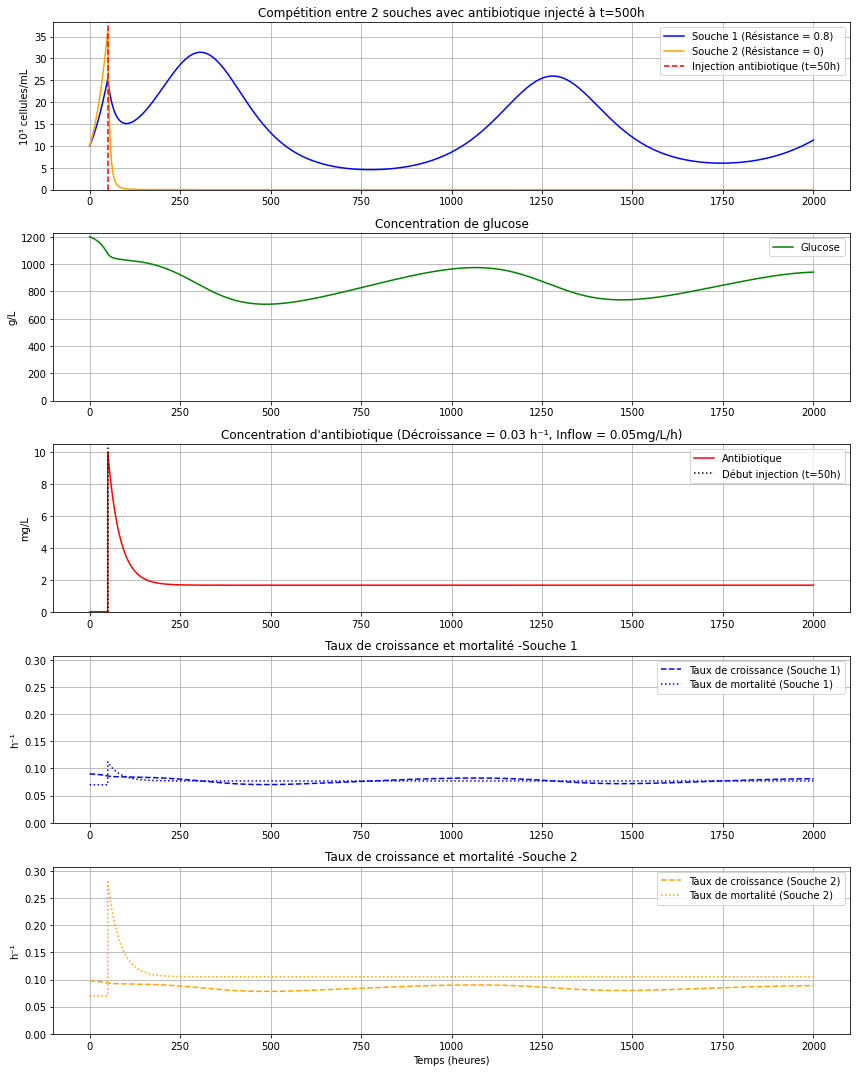

In [72]:
import numpy as np
import matplotlib.pyplot as plt
# =============================================# PARAMÈTRES POUR LES SOUCHES# =============================================
# Souche 1
rmax_1 = 0.15 # Taux de croissance maximal (h⁻¹)
m0_1 = 0.07 # Taux de mortalité de base (h⁻¹)
K_1 = 800 # Constante de demi-saturation (g/L)
resistance_1 = 0.8 # Résistance à l'antibiotique (0 = aucune, 1 = totale)
# Souche 2
rmax_2 = 0.15 # Taux de croissance maximal (h⁻¹)
m0_2 = 0.07 # Taux de mortalité de base (h⁻¹)
K_2 = 650 # Constante de demi-saturation (g/L)
resistance_2 = 0 # Résistance à l'antibiotique
# =============================================# PARAMÈTRES DU GLUCOSE# =============================================
initial_glucose = 1200 # Concentration initiale de glucose (g/L)
glucose_inflow = 1 # Flux entrant de glucose (g/L/h)
# =============================================# PARAMÈTRES DE L'ANTIBIOTIQUE# =============================================
initial_antibiotic = 10 # Concentration initiale d'antibiotique (mg/L)
antibiotic_intensity = 3 # Intensité (0 = aucun effet, 1 = mortalité doublée)
antibiotic_decay = 0.03 # Taux de décroissance naturelle (h⁻¹)
antibiotic_inflow = 0.05 # Flux entrant d'antibiotique (mg/L/h)
antibiotic_start_time = 50 # Temps (en heures) avant l'injection
# =============================================# CONDITIONS INITIALES# =============================================
C0_1 = 10 # Concentration initiale de la souche 1 (10³ cellules/mL)
C0_2 = 10 # Concentration initiale de la souche 2 (10³ cellules/mL)
# =============================================# PARAMÈTRES DE LA SIMULATION# =============================================
dt = 0.1 # Pas de temps (h)
T = 2000 # Durée totale (h)
N_steps = int(T / dt)
# =============================================# INITIALISATION DES TABLEAUX# =============================================
C1 = np.zeros(N_steps)
C2 = np.zeros(N_steps)
glucose_level = np.zeros(N_steps)
antibiotic_level = np.zeros(N_steps)
growth_rate_1 = np.zeros(N_steps)
growth_rate_2 = np.zeros(N_steps)
mortality_rate_1 = np.zeros(N_steps)
mortality_rate_2 = np.zeros(N_steps)
#Conditions initiales
C1[0] = C0_1
C2[0] = C0_2
glucose_level[0] = initial_glucose
antibiotic_level[0] = 0
growth_rate_1[0] = rmax_1 * glucose_level[0] / (K_1 + glucose_level[0])
growth_rate_2[0] = rmax_2 * glucose_level[0] / (K_2 + glucose_level[0])
mortality_rate_1[0] = m0_1
mortality_rate_2[0] = m0_2
# =============================================# SIMULATION# =============================================
for i in range(1, N_steps):
    current_time = i * dt
    # Calcul des taux de croissance
    r_1 = rmax_1 * glucose_level[i-1] / (K_1 + glucose_level[i-1])
    r_2 = rmax_2 * glucose_level[i-1] / (K_2 + glucose_level[i-1])
    # Mise à jour de l'antibiotique (CORRIGÉ)
    if current_time < antibiotic_start_time:
        antibiotic_level[i] = 0
    else:
        if antibiotic_level[i-1] == 0: # Premier pas après l'injection
            antibiotic_level[i] = initial_antibiotic
        else:
            antibiotic_level[i] = antibiotic_level[i-1] * (1 -antibiotic_decay * dt) + antibiotic_inflow* dt
    # Effet de l'antibiotique sur la mortalité
    if antibiotic_level[i] > 0:
        antibiotic_effect_1 = antibiotic_intensity * (antibiotic_level[i] / initial_antibiotic) * (1 -resistance_1)
        antibiotic_effect_2 = antibiotic_intensity * (antibiotic_level[i] / initial_antibiotic) * (1 -resistance_2)
    else:
            antibiotic_effect_1 = 0
            antibiotic_effect_2 = 0
    m_1 = m0_1 * (1 + antibiotic_effect_1)
    m_2 = m0_2 * (1 + antibiotic_effect_2)
    #Mise à jour des populations
    C1[i] = C1[i-1] + dt * (r_1 -m_1) * C1[i-1]
    C2[i] = C2[i-1] + dt * (r_2 -m_2) * C2[i-1]
    # Consommation de glucose
    glucose_consumption = (r_1 * C1[i-1] + r_2 * C2[i-1])
    glucose_level[i] = glucose_level[i-1] -dt * glucose_consumption + glucose_inflow * dt
    # Stockage des taux
    growth_rate_1[i] = r_1
    growth_rate_2[i] = r_2
    mortality_rate_1[i] = m_1
    mortality_rate_2[i] = m_2
    
# =============================================# TEMPS POUR L'AXE DES ABCISSES# =============================================
time = np.linspace(0, T, N_steps)
# =============================================# CALCUL DES ÉCHELLES COMMUNES POUR LES TAUX# =============================================#
#Trouver le maximum global pour les taux de croissance et mortalité
max_growth = max(np.max(growth_rate_1), np.max(growth_rate_2))
max_mortality = max(np.max(mortality_rate_1), np.max(mortality_rate_2))
y_max_rates = max(max_growth, max_mortality) * 1.1 # +10% de marge
# =============================================# TRACÉ DES COURBES# =============================================
plt.figure(figsize=(12, 15))
# 1. Populations bactériennes
plt.subplot(5, 1,1)
plt.plot(time, C1, label=f'Souche 1 (Résistance = {resistance_1})', color='blue')
plt.plot(time, C2, label=f'Souche 2 (Résistance = {resistance_2})', color='orange')
plt.axvline(x=antibiotic_start_time, color='red', linestyle='--', label=f'Injection antibiotique (t={antibiotic_start_time}h)')
plt.title('Compétition entre 2 souches avec antibiotique injecté à t=500h')
plt.ylabel('10³ cellules/mL')
plt.legend()
plt.grid(True)
plt.ylim(bottom=0)
# 2. Concentration de glucose
plt.subplot(5, 1, 2)
plt.plot(time, glucose_level, label='Glucose', color='green')
plt.title('Concentration de glucose')
plt.ylabel('g/L')
plt.legend()
plt.grid(True)
plt.ylim(bottom=0)
# 3. Concentration d'antibiotique
plt.subplot(5, 1, 3)
plt.plot(time, antibiotic_level, label='Antibiotique', color='red')
plt.axvline(x=antibiotic_start_time, color='black', linestyle=':', label=f'Début injection (t={antibiotic_start_time}h)')
plt.title(f'Concentration d\'antibiotique (Décroissance = {antibiotic_decay} h⁻¹, Inflow = {antibiotic_inflow}mg/L/h)')
plt.ylabel('mg/L')
plt.legend()
plt.grid(True)
plt.ylim(bottom=0)
# 4. Taux de croissance et mortalité (Souche 1)
plt.subplot(5, 1, 4)
plt.plot(time, growth_rate_1, label='Taux de croissance (Souche 1)', color='blue', linestyle='--')
plt.plot(time, mortality_rate_1, label='Taux de mortalité (Souche 1)', color='blue', linestyle=':')
plt.title('Taux de croissance et mortalité -Souche 1')
plt.ylabel('h⁻¹')
plt.legend()
plt.grid(True)
plt.ylim(bottom=0, top=y_max_rates)
# Échelle commune# 5. Taux de croissance et mortalité (Souche 2)
plt.subplot(5, 1, 5)
plt.plot(time, growth_rate_2, label='Taux de croissance (Souche 2)', color='orange', linestyle='--')
plt.plot(time, mortality_rate_2, label='Taux de mortalité (Souche 2)', color='orange', linestyle=':')
plt.title('Taux de croissance et mortalité -Souche 2')
plt.xlabel('Temps (heures)')
plt.ylabel('h⁻¹')
plt.legend()
plt.grid(True)
plt.ylim(bottom=0, top=y_max_rates) 
# Même échelle que le graphique 4
plt.tight_layout()
plt.show()

1.Avec l'injection de l'antibiotique, les 2 souches meurent très rapidement.

2.Ici, la souche 1 connait une légere variation décroissante lors de l'injection, mais reprend rapidement sa croissance. La souche 2 elle finit par mourir (on remarque la différence du taux de mortalité des 2 à l'injection).

3.Ici, paradoxalement, c'est la souche 2, non résistante, qui finit par survivre. Une fois l'antibiotique completement disparu du milieu, elle finit par se remettre à un niveau d'équilibre, apres une augmentation massive et rapide de sa concentration. La souche résistante elle tiens le choc lors de l'injection mais semble souffrir de l'absence d'antibiotique lorsque assez de temps a passé.

4.Ici, on garde une certaine quantité constante d'antibiotique présente dans le milieux apres l'injection. On voit que la souche résistante atteint très vite l'équilibre, alors que l'autre meurt dés l'injection, et n'arrive pas à revenir à l'équilibre, suite à la diffusion constante d'antibiotique

5.La pollution résiduelle permet aux souches résistantes de survivre, elle devient même obligatoire pour leur survie, tandis que les souches sauvages ne parviennent pas à survivre à cette pollution. Cela permet par séléction, de ne laisser que les souches résistantes se diviser.

Partie 2. Séléction et Dérive génétique.

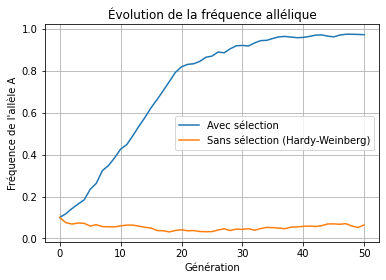

In [73]:
import numpy as np
import matplotlib.pyplot as plt
# Simulation
TAILLE_POP = 1000
GENERATIONS = 50
# Fréquence initiale de l'allèle A
freq_A_initiale = 0.1
# Valeurs sélectives (fitness)
# Cas 1 : sélection (ex : antibiotique ou stress)
fitness_selection = {"AA": 1.0,
                     "Aa": 0.9,
                     "aa": 0.7}
# Cas 2 : pas de sélection (équilibre de Hardy-Weinberg)
fitness_neutre = {"AA": 1.0,
                  "Aa": 1.0,
                  "aa": 1.0}
# Génération d'une population
def generer_population(freq_A, taille):
    freq_a = 1 -freq_A
    probabilites = [
        freq_A ** 2,# AA
        2 * freq_A * freq_a, # Aa
        freq_a ** 2 # aa
    ]
    return np.random.choice(["AA", "Aa", "aa"], size=taille, p=probabilites)
# Calcul de la fréquence allélique
def calcul_freq_A(population):
    nb_A = sum(genotype.count("A") for genotype in population)
    return nb_A / (2 * len(population))
# Application de la sélection
def appliquer_selection(population, fitness):
    poids = [fitness[g] for g in population]
    total = sum(poids)
    probabilites = [p / total for p in poids]
    return np.random.choice(population, size=len(population), p=probabilites)
# Simulation de l'évolution
def simuler(fitness):
    freq_A = freq_A_initiale
    frequences = [freq_A] # Initialisation de la liste
    population = generer_population(freq_A, TAILLE_POP)
    for i in range(GENERATIONS):
        population = appliquer_selection(population, fitness)
        freq_A = calcul_freq_A(population)
        population = generer_population(freq_A, TAILLE_POP)
        frequences.append(freq_A)
    return frequences
# Lancement des simulations
freq_selection = simuler(fitness_selection)
freq_neutre = simuler(fitness_neutre)
# Tracé des courbes
plt.figure()
plt.plot(freq_selection, label="Avec sélection")
plt.plot(freq_neutre, label="Sans sélection (Hardy-Weinberg)")
plt.xlabel("Génération")
plt.ylabel("Fréquence de l'allèle A")
plt.title("Évolution de la fréquence allélique")
plt.legend()
plt.grid(True)
plt.show()

On remarque sur ce graphique que la fréquence allélique de A reste plus ou moins égales dans une simulation sans séléction (environ égale à 0.1) sur les 50 générations.Cela indique que l'allèle a est le dominant dans une simulation sans séléction naturelle.
Dans la simulation avec séléction en revanche, f(A) écrase completement f(a), et finit par tendre vers 1, entrainant la disparition de a. A est devient un allèle très dominant, car il confére un énorme avantage à son porteur par rapport à a.